#### Si richiede di verificare le dimensioni del dataset e i relativi metadati

In [1]:
import pandas as pd 
# Per importare la libreria esterna "PANDAS"


df = pd.read_csv("Datasets/owid-covid-data.csv") 
# Richiamo la funzione "read_csv()" della libreria di pandas, per caricare il dataset.


f"Le righe del dataset sono: {df.shape[0]}. Le colonne sono: {df.shape[1]}"
# Tramite il metodo shape, mi faccio restituire una tupla che, utilizzando l'indexing, mi permette di estrapolare 
#   il primo valore (con l'indice 0) e il secondo (con l'indice 1), relativi al dato delle righe e delle colonne.
# f"{}" è una variante più comoda della funzione print, che si scrive: print("").

'Le righe del dataset sono: 429435. Le colonne sono: 67'

In [2]:
# Visualizzazione metadati. 
df.info()

# Avrei potuto utilizzare: df.dtypes per mostrare i tipi di dati delle colonne, 
#   df.columns per visualizzare i nomi delle colonne e df.index per le righe.
# Utilizzo df.info() perchè raggruppa tutti e tre, e restituisce anche altre informazioni, 
#   tipo la grandezza del dataset.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  object 
 1   continent                                   402910 non-null  object 
 2   location                                    429435 non-null  object 
 3   date                                        429435 non-null  object 
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                                  410608 non-null  float64
 9   new_deaths_smoothed                         409378 non-null  float64
 

In [3]:
df["date"]=pd.to_datetime(df["date"],format='%Y-%m-%d')
# Ho mdificato il tipo di dato della colonna "date", in quanto ho visto dalla cella prima, che era in formato "object", ovvero formato stringa.
#   Per renderlo effettivo, ho sovrascritto la colonna "date", con il risultato della funzione "pd.to_datetime()".

In [4]:
df.isnull().sum()
# Controllo per vedere se ci sono valori nulli e quanti sono per le varie colonne.

iso_code                                        0
continent                                   26525
location                                        0
date                                            0
total_cases                                 17631
                                            ...  
population                                      0
excess_mortality_cumulative_absolute       416024
excess_mortality_cumulative                416024
excess_mortality                           416024
excess_mortality_cumulative_per_million    416024
Length: 67, dtype: int64

In [5]:
df["continent"].unique()
# Con il metodo unique, vedo che ci sono dei valori nulli nella colonna "continent".

array(['Asia', nan, 'Europe', 'Africa', 'Oceania', 'North America',
       'South America'], dtype=object)

In [6]:
df[~df["continent"].notna()]
# Ho usato questo codice per far vedere che ci sono diverse righe con il valore NaN nella colonna continent, procedo a togliere queste.

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
1674,OWID_AFR,NaN,Africa,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,1426736614,NaN,NaN,NaN,NaN
1675,OWID_AFR,NaN,Africa,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,1426736614,NaN,NaN,NaN,NaN
1676,OWID_AFR,NaN,Africa,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,1426736614,NaN,NaN,NaN,NaN
1677,OWID_AFR,NaN,Africa,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,1426736614,NaN,NaN,NaN,NaN
1678,OWID_AFR,NaN,Africa,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,1426736614,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
424408,OWID_WRL,NaN,World,2024-08-10,NaN,NaN,NaN,NaN,NaN,NaN,...,34.635,60.13,2.705,72.58,0.737,7975105024,NaN,NaN,NaN,NaN
424409,OWID_WRL,NaN,World,2024-08-11,NaN,NaN,NaN,NaN,NaN,NaN,...,34.635,60.13,2.705,72.58,0.737,7975105024,NaN,NaN,NaN,NaN
424410,OWID_WRL,NaN,World,2024-08-12,NaN,NaN,NaN,NaN,NaN,NaN,...,34.635,60.13,2.705,72.58,0.737,7975105024,NaN,NaN,NaN,NaN
424411,OWID_WRL,NaN,World,2024-08-13,NaN,NaN,NaN,NaN,NaN,NaN,...,34.635,60.13,2.705,72.58,0.737,7975105024,NaN,NaN,NaN,NaN


In [7]:
df = df[df["continent"].notna()]
# Quindi procedo a toglierli, in quanto non utili per l'analisi, dato che ci viene chiesto di farla sui continenti. 
# Potevo utiizzare anche "  df.dropna(subset="continent")  ". Nel mio codice, invece, ho preso i valori non nulli e li ho sostituiti nel dataframe, 
#   eliminando di conseguenza i nulli.
# Facendo partire nuovamente la cella con il codice" df["continent"].unique() ", ho visto che i nulli sono stati tolti.

#### Si chiede di trovare, per ogni continente: 

    a. il numero di casi fin dall'inizio della pandemia 
    b. la percentuale rispetto al totale mondiale del numero di casi

In [8]:
listacontinenti = df["continent"].sort_values().unique()
# Prendo i valori della colonna continenti e li ordino in maniera crescente, poi prendo i valori unici e li metto nella variabile.

groupby_continenti = df.groupby("continent")["new_cases"].sum()
totale_mondiale = df.groupby("continent")["new_cases"].sum().sum()
totale_mondiale = int(totale_mondiale)
# Ho utilizzato groupby, che permette di raggruppare per continenti (avendo anche valori unici) 
#   e fa la somma dei valori contenuti nella colonna "new_cases")
# Il groupby con doppio metodo ".sum()" mi permette di sommare i valori già sommati dal raggruppamento, avendo cosi il totale mondiale.
# Infine ho convertito la variabile "totale_mondiale" in intero, cosi non mostrava a schermo il valore 0 dopo la virgola: "775935057.0"

print(f"\nIl totale mondiale del numero dei casi è: {totale_mondiale}\n")
print("Numero di casi per continente e percentuale rispetto al totale mondiale del numero di casi:\n")

indice = 0
for continente in listacontinenti: 
        casi_continente = groupby_continenti.iloc[indice]
        casi_continente = int(casi_continente)
        percentuale = (groupby_continenti.iloc[indice] / totale_mondiale)*100
        print(f"{continente:<14} {casi_continente:<10} {percentuale:.2f}%")
        indice += 1

# Ciclo for per stampare il nome del continente, la somma dei valori per continente, e la percentuale rispetto al totale mondiale.
# Creata la variabile "indice" che si incrementa in ogni ciclo, per utilizzarlo per estrapolare i numeri dei casi per ogni continente. 
# Convertita la variabile "casi_continente" in intero, cosi non mostrava a schermo il valore esempio: "13146831.0".
# Creata la variabile percentuale, cosi da poter calcolare la percentuale rispetto al totale mondiale del numero di casi.
# Utilizzato l'allineamento delle colonne, mantenendo cosi una lunghezza fissa tra di loro, che ho potuto modificare nei primi due casi. 
# Infine ho scritto "percentuale:.2f" che mi permette visualizzare a schermo il numero con due cifre decimali.


Il totale mondiale del numero dei casi è: 775935057

Numero di casi per continente e percentuale rispetto al totale mondiale del numero di casi:

Africa         13146831   1.69%
Asia           301564180  38.86%
Europe         252916868  32.60%
North America  124492698  16.04%
Oceania        15003468   1.93%
South America  68811012   8.87%


#### Selezionare i dati relativi all'Italia nel 2022 e mostrare con dei grafici adeguati:

    a. l'evoluzione del casi totali dall'inizio alla fine dell'anno 
    b. il numero di nuovi casi rispetto alla data 
        k. poiché i nuovi casi vengono registrati settimanalmente, filtrare via i dati che non hanno misurazioni

In [9]:
# estrarre il dataframe relativo alla nazione "Italia" e all'anno 2022.
italia = df["location"] == "Italy"
anno_2022 = df["date"].dt.year == 2022
italia_2022 = italia & anno_2022
italia_2022 = df[italia_2022]

# Ho creato due filtri, uno per estrapolare le righe relative alla nazione "Italy", l'altro per estrapolare le righe relative al solo anno 2022,
#   calcolandolo con l'attributo di pandas ".dt.year".

# Infine ho unito i due filtri in un unico filtro chiamato italia_2022. 
# Il filtro in se non bastava, in quanto mi avrebbe restituito dei valori booleani, quindi ho scritto il codice "df[italia_2022]", 
#   che mi permette di estrapolare il dataframe con quello specifico filtro, e ho inserito il risultato all'interno 
#   della stessa variabile "italia_2022", potendo richiamare, quando mi serve, quello specifo dataframe con le informazioni che mi servono.

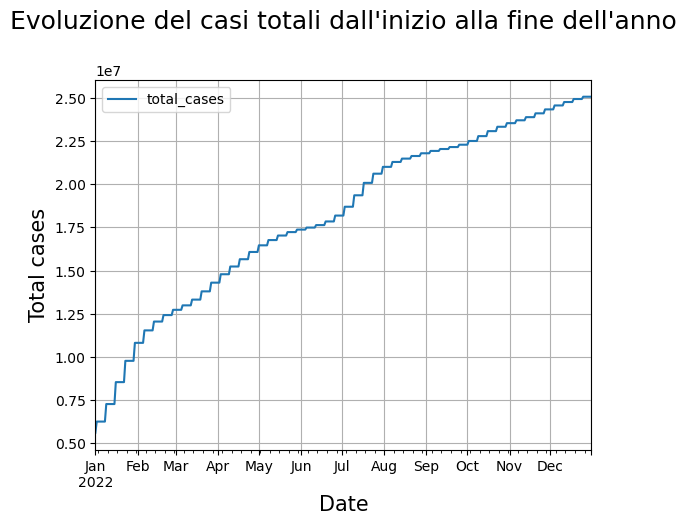

In [10]:
# l'evoluzione del casi totali dall'inizio alla fine dell'anno 

import matplotlib.pyplot as plt

ax = italia_2022.plot(kind="line", x="date", y="total_cases")

ax.set_xlabel("Date", size=15)
ax.set_ylabel("Total cases", size=15)
ax.set_title("Evoluzione del casi totali dall'inizio alla fine dell'anno\n", size=18)

plt.grid(True)
plt.show()


#  Ho utilizzato il grafico con linea, in quanto ci serviva visualizzare un andamento nel tempo.
#  Ho cercato e trovato un modo per assegnare un titolo al grafico, tramite plt.set_title e inserito anche plt.setxlabel e plt.setylabel 
#  per sistemare l'estetica del grafico, importando la libreria matplotlib.pyplot, ma veniva fuori un testo sopra il grafico 
#  (che puoi vedere, commentando i codici "plt.grid(True) - plt.show()" di seguito :
#  "Text(0.5, 1.0, "Evoluzione del casi totali dall'inizio alla fine dell'anno\n")".

#  Quindi ho trovato che si poteva scrivere anche cosi: "ax.set_title" e ciò ha risolto il problema. 

#  Ho comunque modificato anche i vari .set (set_xlabel, set_ylabel e .set_title) sostituendolo con "ax." perchè altrimenti restituiva errore. 
#  Con i "set_ label" ho potuto cambiare il nome delle ascisse e ordinate, e la grandezza del font. 
#  Con ax.set_title, ho potuto impostare il titolo, con la sua grandezza. 

#  Ho inserito questo codice, per far vedere la griglia nello sfondo: "plt.grid(True)", si vedono meglio i vari livelli del conteggio.

#  Tutto ciò, per renderlo quanto più pulito possibile, nella visualizzazione. 

In [11]:
#  k. poiché i nuovi casi vengono registrati settimanalmente, filtrare via i dati che non hanno misurazioni
italia_2022 = italia_2022[italia_2022["new_cases"] != 0]

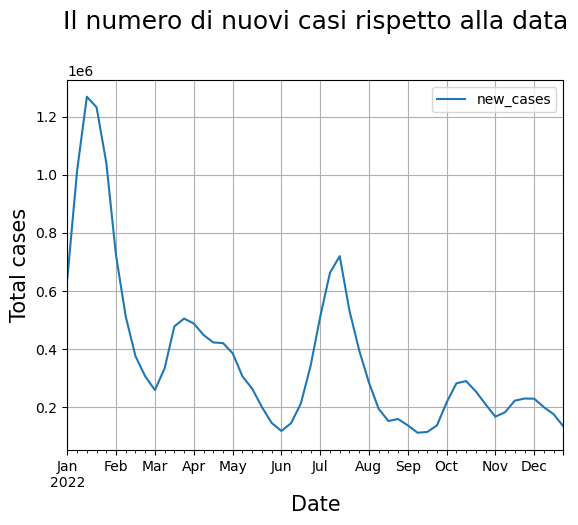

In [12]:
# il numero di nuovi casi rispetto alla data 

import matplotlib.pyplot as plt

ax = italia_2022.plot(kind="line", x="date", y="new_cases")

ax.set_xlabel("Date", size=15)
ax.set_ylabel("Total cases", size=15)
ax.set_title("Il numero di nuovi casi rispetto alla data\n", size=18)

plt.grid(True)
plt.show()

#  Ho utilizzato il grafico con linea, in quanto ci serviva visualizzare un andamento nel tempo.
#  Ho inserito questo codice, per far vedere la griglia nello sfondo: "plt.grid(True)", si vedono meglio i vari livelli del conteggio.

#  Ho eseguito un codice praticamente uguale a quello di prima, cambiando solo i dati per la creazione del grafico.

#  Tutto ciò, per renderlo quanto più pulito possibile, nella visualizzazione. 

#### Riguardo le nazioni di Italia, Germania e Francia mostrare in un boxplot la differenza tra queste nazioni riguardo il numero di pazienti in terapia intensiva (Intensive Care Unit, ICU) da maggio 2022 (incluso) ad aprile 2023 (incluso) 
    a. scrivere un breve commento a riguardo

In [13]:
# Estrazione dataframe con le condizioni richieste

nazioni = (df["location"] == "Italy") | (df["location"] == "Germany") | (df["location"] == "France")
maggio_aprile = (df["date"] >= "2022-05-01") & (df["date"] <= "2023-04-30")
nazioni_maggio_2022_2023 = nazioni & maggio_aprile
nazioni_maggio_2022_2023 = df[nazioni_maggio_2022_2023]

# Come nell'esercizio di prima, abbiamo bisogno di 3 filtri, quello relativo alle nazioni (ho utilizzato la condizione logica "OR").
# Dopodichè ci serve il range temporale che va da maggio 2022 ad aprile 2023, utilizzando la condizione logica "AND".
# I filtri di per se non bastavano, in quanto mi avrebbero restituito dei valori booleani, quindi ho scritto il codice "df[nazioni_maggio_2022_2023]", 
#   che mi permette di estrapolare il dataframe con quello specifico filtro, e ho inserito il risultato all'interno 
#   della stessa variabile "nazioni_maggio_2022_2023", potendo richiamare, quando mi serve, quello specifo dataframe con le informazioni che mi servono.

# IL COMMENTO RICHIESTO NELAL TRACCIA, E' SCRITTO NELLA CELLA SOTTO.

#### Il grafico di seguito, dimostra come l'Italia è riuscita a gestire al meglio la situazione del covid nel periodo che va da maggio 2022 ad aprile 2023, ottendendo un valore di ICU estremamente minore rispetto alle nazioni Francia e Germania. Andando ad analizzare nazione per nazione abbiamo: 

* L'Italia ha valori sotto i 500, e si concentra maggiormente sul box e sul terzo quartile. La mediana è di circa 250.
* La Francia ha un range di valori che va da poco meno di 750 a sopra i 1500, avendo una concentrazione maggiore nel terzo quartile. La mediana si attesta sui 1000
* La Germania ha il numero più alto dei tre, e più estesa nei valori che vanno dai 500 a più di 1750. La mediana comunque si attesta a 1000 come la Francia, ma ha i dato più negativo delle tre, in quanto i valori si concentrano maggiormente tra i 1250 e i 1800 circa, quindi nel terzo quartile. 

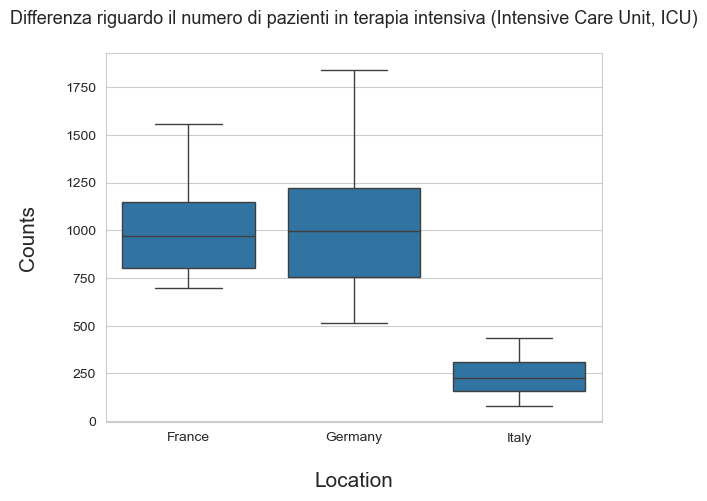

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, ax = plt.subplots()

sns.boxplot(data=nazioni_maggio_2022_2023, x="location", y="icu_patients", ax=ax)

ax.set_xlabel('\nLocation', size=15)
ax.set_ylabel('Counts\n', size=15)

ax.set_title('Differenza riguardo il numero di pazienti in terapia intensiva (Intensive Care Unit, ICU)\n', size=13)

plt.show()

# Ho utilizzato questa volta seaborn perchè serviva utilizzare il "boxplot". Perciò ho dovuto modificare un pò il testo per la creazione del grafico
#  rispetto ai precedenti, con queste modifiche: 
# Mi dava un problema con ax.set_title, inserendo quest' all'inizio, ho risolto: "fig, ax = plt.subplots()". In sostanza, da quanto ho capito, 
#  si tratta di un modo per avere più controllo sul grafico, creando la figura (fig) e gli assi (ax). Sono sincero, non so bene come funzioni. 
# Ho inserito la riga "sns.set_style("whitegrid")" per poter avere l'equivalente di "plt.grid(True)", ma in seaborn.

#### Riguardo le nazioni di Italia, Germania, Francia e Spagna in tutto il 2023: 
    a. mostrare la somma dei pazienti ospitalizzati per ognuna 
    b. se ci sono dati nulli, con un breve commento scrivere se può essere possibile gestirli tramite sostituzione o meno

In [15]:
# #estrazione dataframe con le condizioni richieste

quattronazioni = (df["location"] == "Italy") | (df["location"] == "Germany") | (df["location"] == "France") | (df["location"] == "Spain")
anno2023 = df["date"].dt.year == 2023
quattronazioni2023 = quattronazioni & anno2023
quattronazioni2023 = df[quattronazioni2023]

# Passaggi praticamente uguali a quelli dei punti precedenti.

# mostrare la somma dei pazienti ospitalizzati per ognuna
print("\nI pazienti ospitalizzati per le nazioni:\n")
groupbyqn23 = quattronazioni2023.groupby("location")["hosp_patients"].sum()
groupbyqn23 = groupbyqn23.reset_index()
groupbyqn23

# Utilizzato metodo groupby sul "dataframe filtrato", estrapolando le "Location" e quindi le nazioni, dove come funzione, 
#   ho usato il ".sum()" sulla colonna "hosp_patients". Il risultato l'ho inserito nella variabile groupbyqn23. 
#   Infine ho utilizzato il metodo ".reset_index()", che riporta "location", anzichè come indice, come colonna per il nuovo dataframe.


I pazienti ospitalizzati per le nazioni:



,location,hosp_patients
0,France,1382574.0
1,Germany,0.0
2,Italy,1175272.0
3,Spain,354602.0


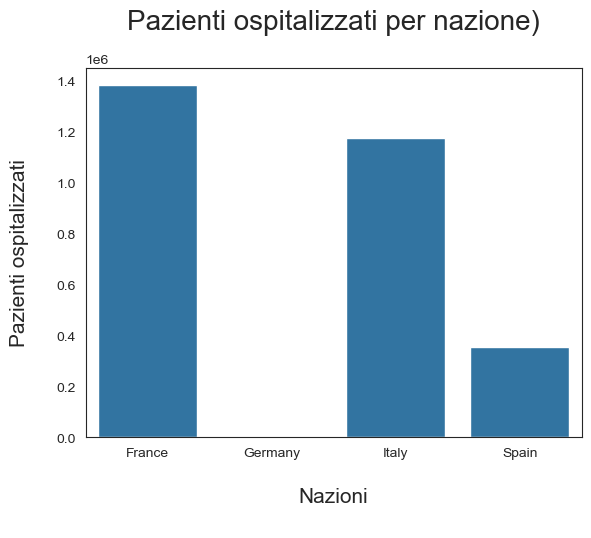

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("white")
fig, ax = plt.subplots()

sns.barplot(data=groupbyqn23, x="location", y="hosp_patients", ax=ax)

ax.set_xlabel('\nNazioni\n', size=15)
ax.set_ylabel('Pazienti ospitalizzati\n', size=15)

ax.set_title('Pazienti ospitalizzati per nazione)\n', size=20)

plt.show()

# Stesse passaggi del grafico precedente. Questa volta ho utilizzato "sns.set_style("white")", in quanto non serviva far vedere la griglia
#   inserendo uno sfondo bianco e una cornice nera.

#### Se ci sono dati nulli, con un breve commento scrivere se può essere possibile gestirli tramite sostituzione o meno

I dati nulli sono presenti per la nazione "Germany". Potrebbero essere sostituiti con uno 0, ma in questo caso specifico non serve, in quanto non dobbiamo fare operazioni sopra questi dati (per esempio somme di valori tra stati), quindi il dato sarebbe comunque inesistente, e perciò ho deciso di lasciarlo cosi. Inoltre non possiamo neanche inserire un valore di media dei dati, in quanto non ne è presente neanche uno. 